# Kolmogorov-Arnold Networks for the Burgers Equation

This notebook studies **KANs** through a clean, verifiable function-approximation problem:
the exact solution field of the 1-D viscous Burgers equation.

The goal is not just to train another model. The notebook connects:

- the **Kolmogorov-Arnold representation viewpoint**
- the practical **KAN layer** with learned univariate edge functions
- a **verified analytical target** via the Cole-Hopf transform
- a reusable implementation with **Pydantic configs**, **OO trainers**, and **notebook-safe plots**
- quantitative verification through **held-out error metrics** and **PDE residual checks**

Primary reference:

- Liu et al. (2024), *KAN: Kolmogorov-Arnold Networks*, arXiv:2404.19756


## 1 — Theory: Why KANs Are Different

Standard MLPs place nonlinearities on **nodes** and use linear weights on edges.
KANs reverse that pattern: each edge carries a **learned univariate function**, and each neuron mainly sums edge responses.

At a high level, a KAN layer computes

$$
y_j = \sum_i \phi_{j,i}(x_i),
$$

where each $\phi_{j,i}$ is a learnable scalar function. In the paper, these edge functions are represented with spline parameterizations plus a simple base function.

This links back to the **Kolmogorov-Arnold representation theorem**, which states that multivariate continuous functions can be expressed through sums and compositions of univariate functions.

Important caveat:

- the theorem is an **existence result**, not a turnkey training guarantee
- practical KANs are a **model class inspired by that theorem**, not a direct constructive proof
- they do not eliminate optimization difficulty or the curse of dimensionality in arbitrary regimes

So the right way to read KAN is: it provides a structured, interpretable function class with strong inductive bias toward low-dimensional separable structure.


## 2 — Theory: The Practical KAN Layer Used Here

This repository implements a compact, stable KAN suitable for scientific-regression notebooks:

1. coordinates $(x,t)$ are normalized to $[-1,1]^2$
2. each edge function is

$$
\phi_{j,i}(z) = w^{(b)}_{j,i} \, b(z) + w^{(s)}_{j,i} \, s_{j,i}(z),
$$

where $b$ is a base activation and $s_{j,i}$ is a learned **piecewise-linear spline**
3. hidden layers sum these edge functions to build increasingly rich latent coordinates

This is faithful to the KAN philosophy while keeping the code small, testable, and easy to inspect.

We use **piecewise-linear hat bases** instead of a more elaborate adaptive-grid spline system because this tutorial prioritizes:

- deterministic behavior
- readable implementation
- reliable smoke testing
- straightforward visualization of learned edge functions


## 3 — Problem Setup: Exact Burgers Supervision

The target field is the exact solution of

$$
u_t + u u_x = \nu u_{xx}, \qquad x \in [-1,1], \quad t \in [0,1],
$$

with

$$
u(x,0) = -\sin(\pi x), \qquad u(-1,t)=u(1,t)=0.
$$

The exact solution is generated with the **Cole-Hopf transform**, so our supervision is analytical rather than numerical. That gives us a strong verification story:

- coarse-grid training points come from a known exact field
- finer-grid evaluation checks interpolation quality
- autograd-based PDE residuals reveal whether the learned surrogate preserves the underlying physics


In [1]:
from pathlib import Path
import sys

import numpy as np
import pandas as pd
import torch
from IPython.display import display

PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / "src").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

SOURCE_ROOT = PROJECT_ROOT / "src"
if str(SOURCE_ROOT) not in sys.path:
    sys.path.insert(0, str(SOURCE_ROOT))

from physics_informed_neural_network.kan.data import build_dataset_splits
from physics_informed_neural_network.kan.pipeline import run_kan_experiment
from physics_informed_neural_network.kan.plotting import (
    apply_plot_style,
    plot_edge_functions,
    plot_residual_distribution,
    plot_solution_comparison,
    plot_time_slices,
    plot_training_history,
)
from physics_informed_neural_network.kan.presets import build_smoke_test_config, build_tutorial_config

apply_plot_style()
pd.set_option("display.float_format", lambda value: f"{value:,.6f}")

## 4 — Pydantic Configuration

The KAN stack is structured as reusable library code:

- `KANExperimentConfig`: top-level experiment contract
- `KANDataConfig`: train/validation/test/evaluation grids
- `PiecewiseLinearKANConfig`: spline-edge architecture
- `KANOptimizationConfig`: optimizer and scheduler settings

The tutorial preset below trains on a coarse grid and evaluates on a much finer grid.


In [2]:
config = build_tutorial_config(output_dir=PROJECT_ROOT / "artifacts" / "notebook_kan")
display(config.model_dump())

{'pde': {'viscosity': 0.00318309886183791,
  'x_min': -1.0,
  'x_max': 1.0,
  't_min': 0.0,
  't_max': 1.0},
 'data': {'train_nx': 33,
  'train_nt': 25,
  'validation_nx': 49,
  'validation_nt': 33,
  'test_nx': 65,
  'test_nt': 41,
  'evaluation_nx': 129,
  'evaluation_nt': 81,
  'seed': 21},
 'model': {'input_dim': 2,
  'hidden_widths': (24, 24),
  'num_knots': 17,
  'spline_domain_min': -1.0,
  'spline_domain_max': 1.0,
  'base_activation': 'silu',
  'hidden_input_activation': 'tanh',
  'use_bias': True,
  'spline_scale_init': 1.0},
 'optimization': {'seed': 7,
  'device': 'cpu',
  'batch_size': 256,
  'epochs': 220,
  'learning_rate': 0.002,
  'weight_decay': 1e-06,
  'scheduler_step': 70,
  'scheduler_gamma': 0.65,
  'grad_clip': 1.0,
  'log_every': 20},
 'artifacts': {'output_dir': PosixPath('/Users/rezami/PycharmProjects/physical-informed-neural-network/artifacts/notebook_kan'),
  'save_artifacts': False}}

In [3]:
splits = build_dataset_splits(config)
dataset_frame = pd.DataFrame(
    [
        {"split": "train", "nx": splits.train.nx, "nt": splits.train.nt, "points": splits.train.n_points},
        {"split": "validation", "nx": splits.validation.nx, "nt": splits.validation.nt, "points": splits.validation.n_points},
        {"split": "test", "nx": splits.test.nx, "nt": splits.test.nt, "points": splits.test.n_points},
        {"split": "evaluation", "nx": splits.evaluation.nx, "nt": splits.evaluation.nt, "points": splits.evaluation.n_points},
    ]
)
display(dataset_frame)

,split,nx,nt,points
0,train,33,25,825
1,validation,49,33,1617
2,test,65,41,2665
3,evaluation,129,81,10449


## 5 — Why This Is a Useful KAN Experiment

This tutorial is deliberately **not** a PINN training run. Instead, it isolates the approximation question:

- Can a KAN learn the Burgers solution field from coarse samples?
- Does that approximation remain accurate on a finer unseen grid?
- What do the learned first-layer edge functions look like?
- Does the learned surrogate still exhibit a small Burgers residual?

That separation is useful because it lets us evaluate the KAN architecture itself before mixing in physics-informed optimization.


## 6 — Train the KAN

In [4]:
experiment = run_kan_experiment(config)

Device: cpu
Datasets: train=25x33 (825 points) validation=33x49 (1617 points) test=41x65 (2665 points) evaluation=81x129 (10449 points)
Model: KolmogorovArnoldNetwork(input_dim=2, hidden=[24,24], knots=17, base_act=silu, hidden_input_act=tanh) (12,361 parameters)
  [KAN    1/220] train_loss=0.790086 val_rel_l2=0.725875 val_mse=0.190627
  [KAN   20/220] train_loss=0.001496 val_rel_l2=0.111882 val_mse=0.004529
  [KAN   40/220] train_loss=0.000302 val_rel_l2=0.107381 val_mse=0.004172
  [KAN   60/220] train_loss=0.000160 val_rel_l2=0.107791 val_mse=0.004204
  [KAN   80/220] train_loss=0.000033 val_rel_l2=0.107508 val_mse=0.004182
  [KAN  100/220] train_loss=0.000024 val_rel_l2=0.107685 val_mse=0.004195
  [KAN  120/220] train_loss=0.000023 val_rel_l2=0.108176 val_mse=0.004234
  [KAN  140/220] train_loss=0.000029 val_rel_l2=0.107674 val_mse=0.004194
  [KAN  160/220] train_loss=0.000009 val_rel_l2=0.108341 val_mse=0.004247
  [KAN  180/220] train_loss=0.000012 val_rel_l2=0.108092 val_mse=0.004

In [5]:
summary_frame = pd.DataFrame([experiment.summary.model_dump()])
display(summary_frame)

,architecture,trainable_parameters,device,train_points,validation_points,test_points,evaluation_points,train_grid,evaluation_grid,test_metrics,evaluation_metrics,residual_metrics
0,"KolmogorovArnoldNetwork(input_dim=2, hidden=[2...",12361,cpu,825,1617,2665,10449,"(33, 25)","(129, 81)","{'relative_l2': 0.16826529447728322, 'mse': 0....","{'relative_l2': 0.2589953553044365, 'mse': 0.0...","{'mean_absolute_residual': 2.6448965359173124,..."


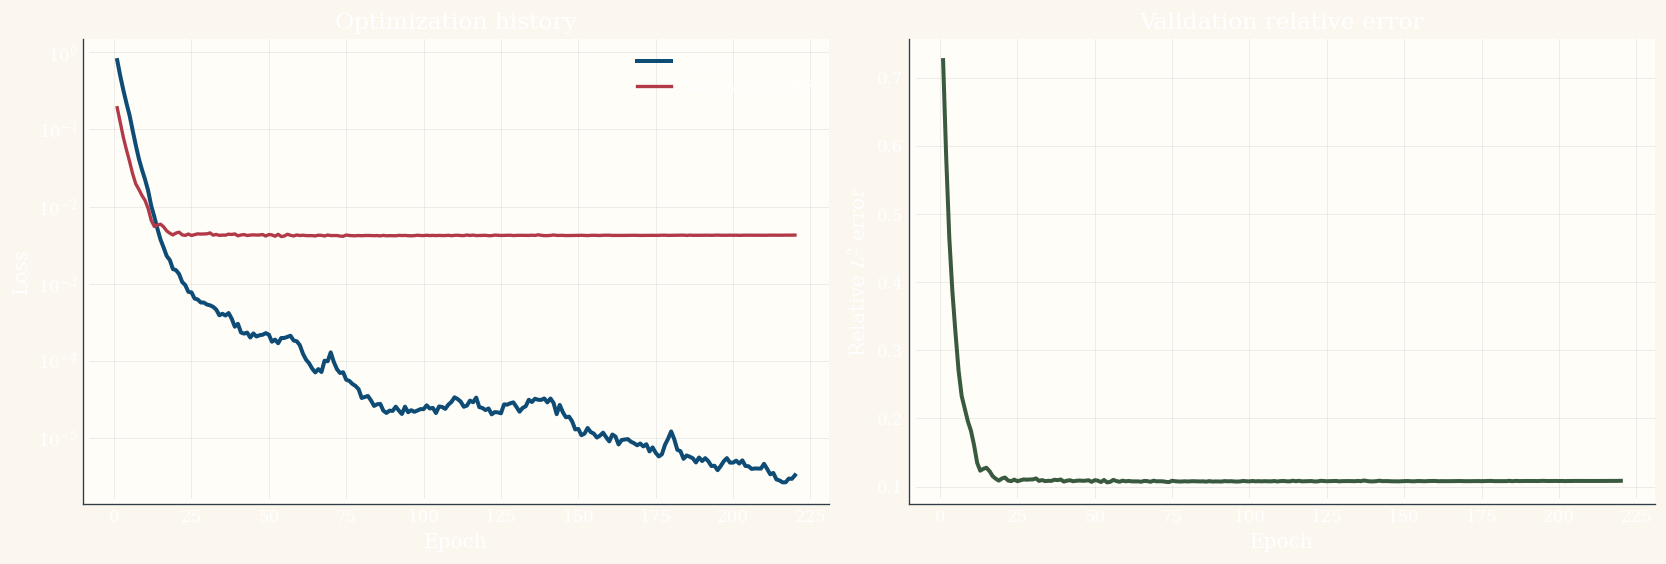

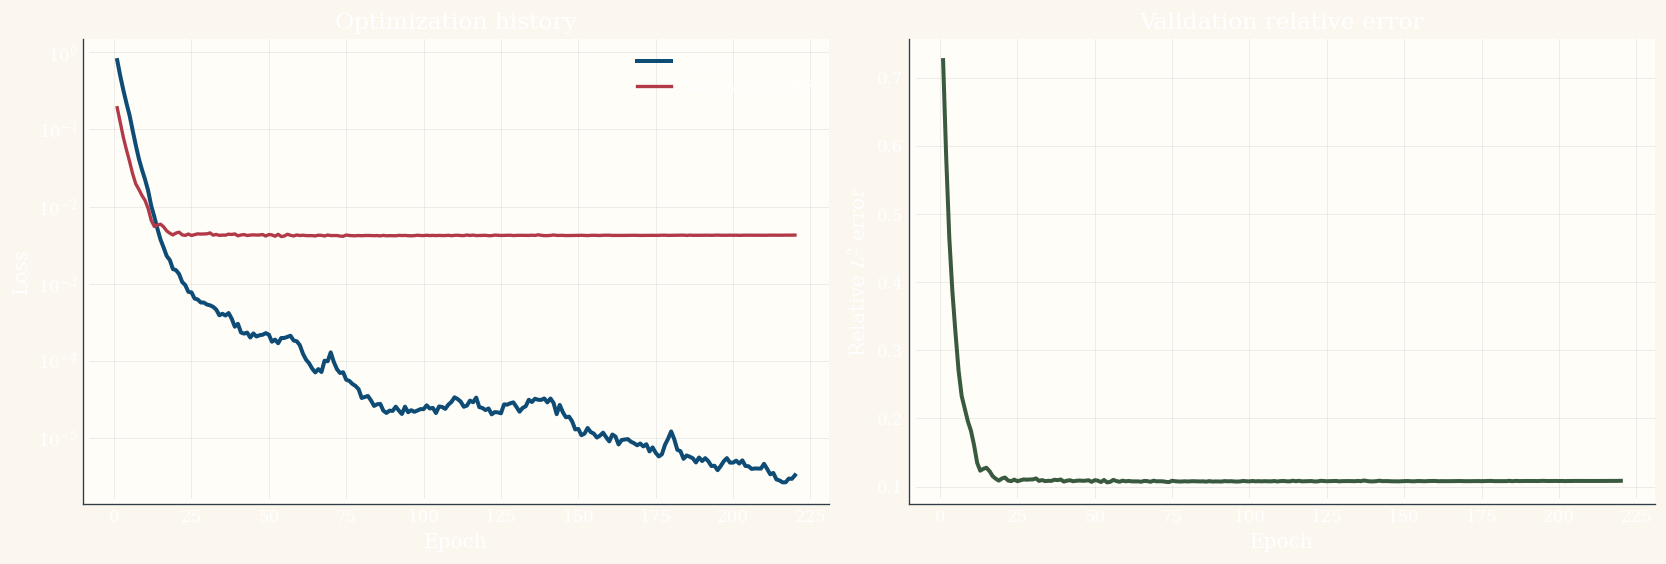

In [6]:
fig_history = plot_training_history(experiment.history)
fig_history

## 7 — Solution Quality on the Dense Evaluation Grid

The model is trained on the coarse train grid but visualized on the much denser evaluation grid.
This is the right place to inspect whether the learned field is smooth, stable, and physically plausible.


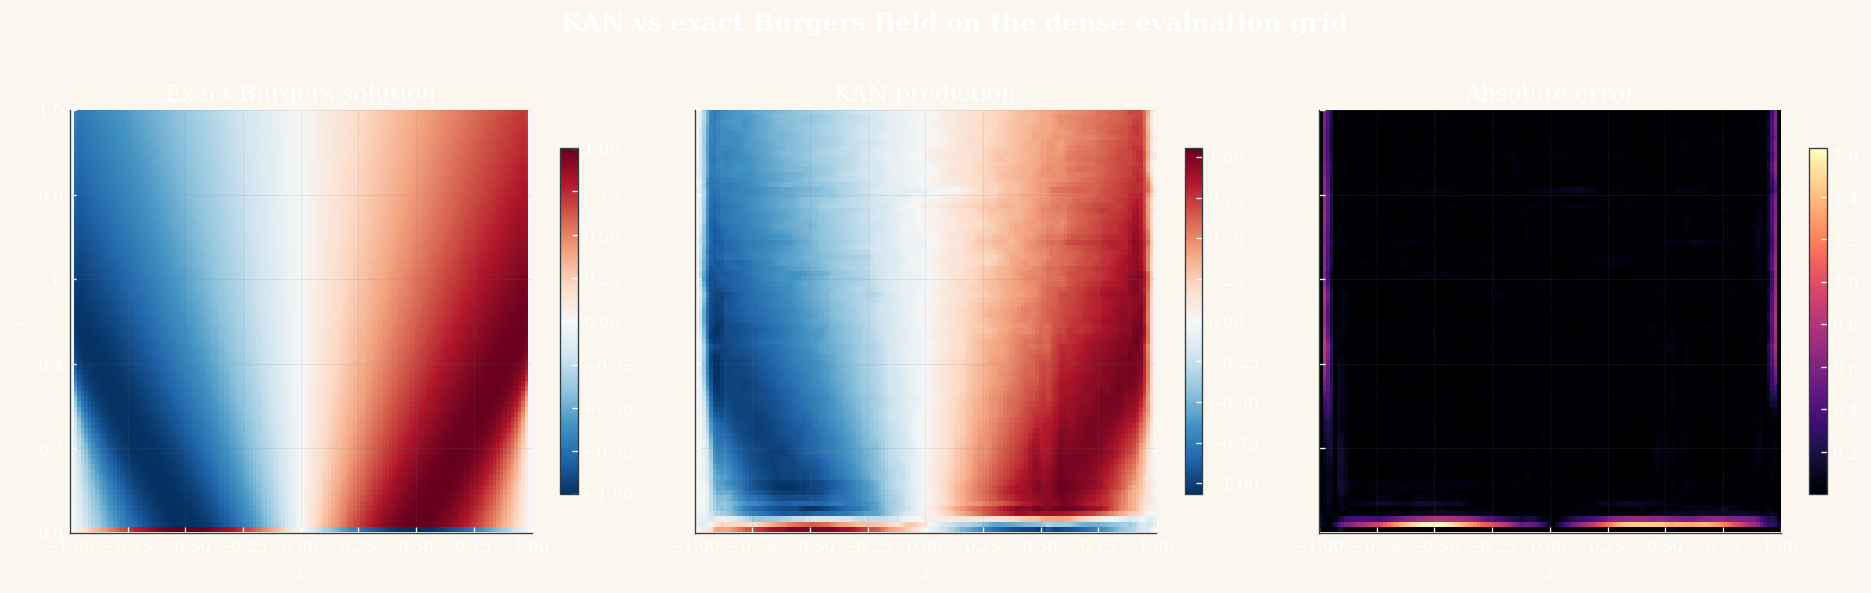

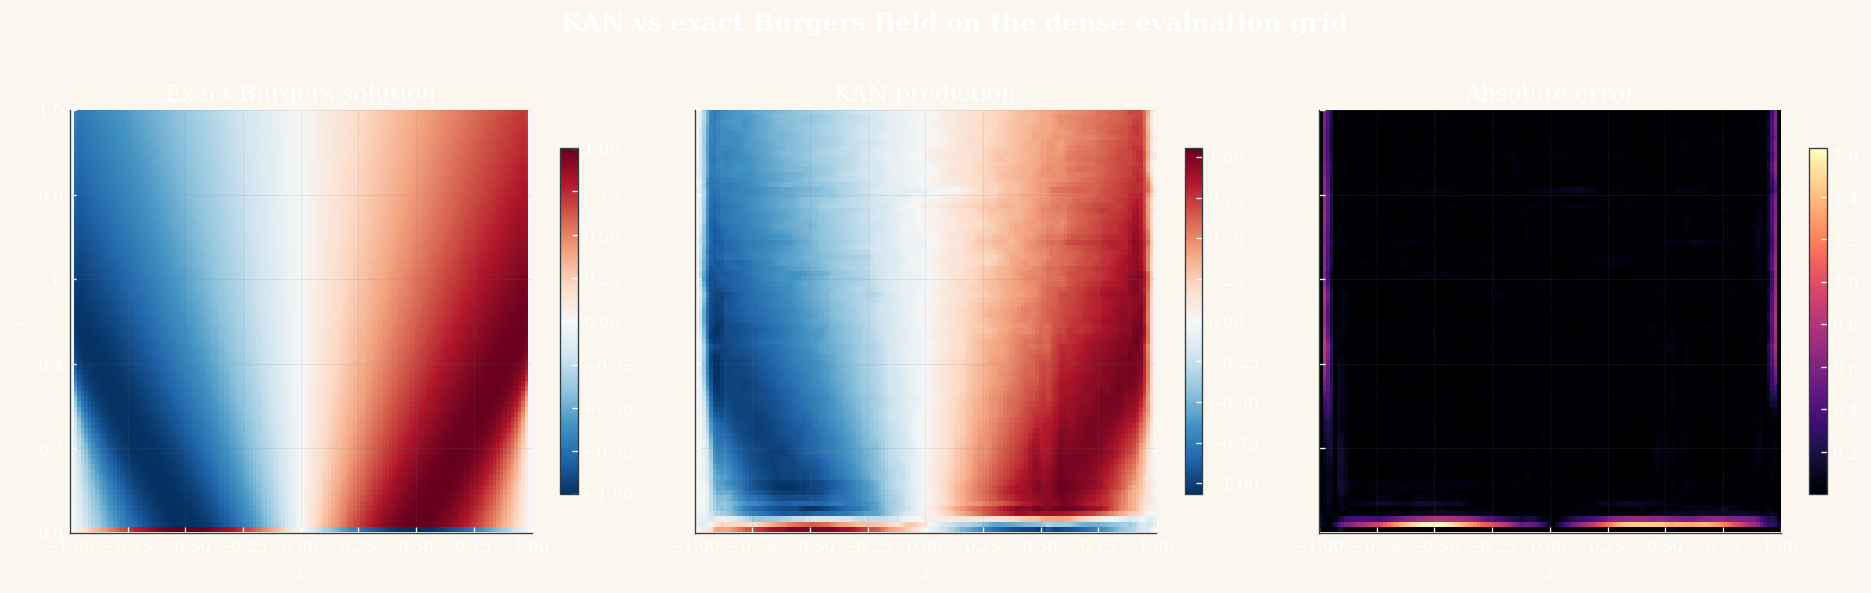

In [7]:
fig_solution = plot_solution_comparison(
    experiment.datasets.evaluation,
    experiment.evaluation_prediction,
    title="KAN vs exact Burgers field on the dense evaluation grid",
)
fig_solution

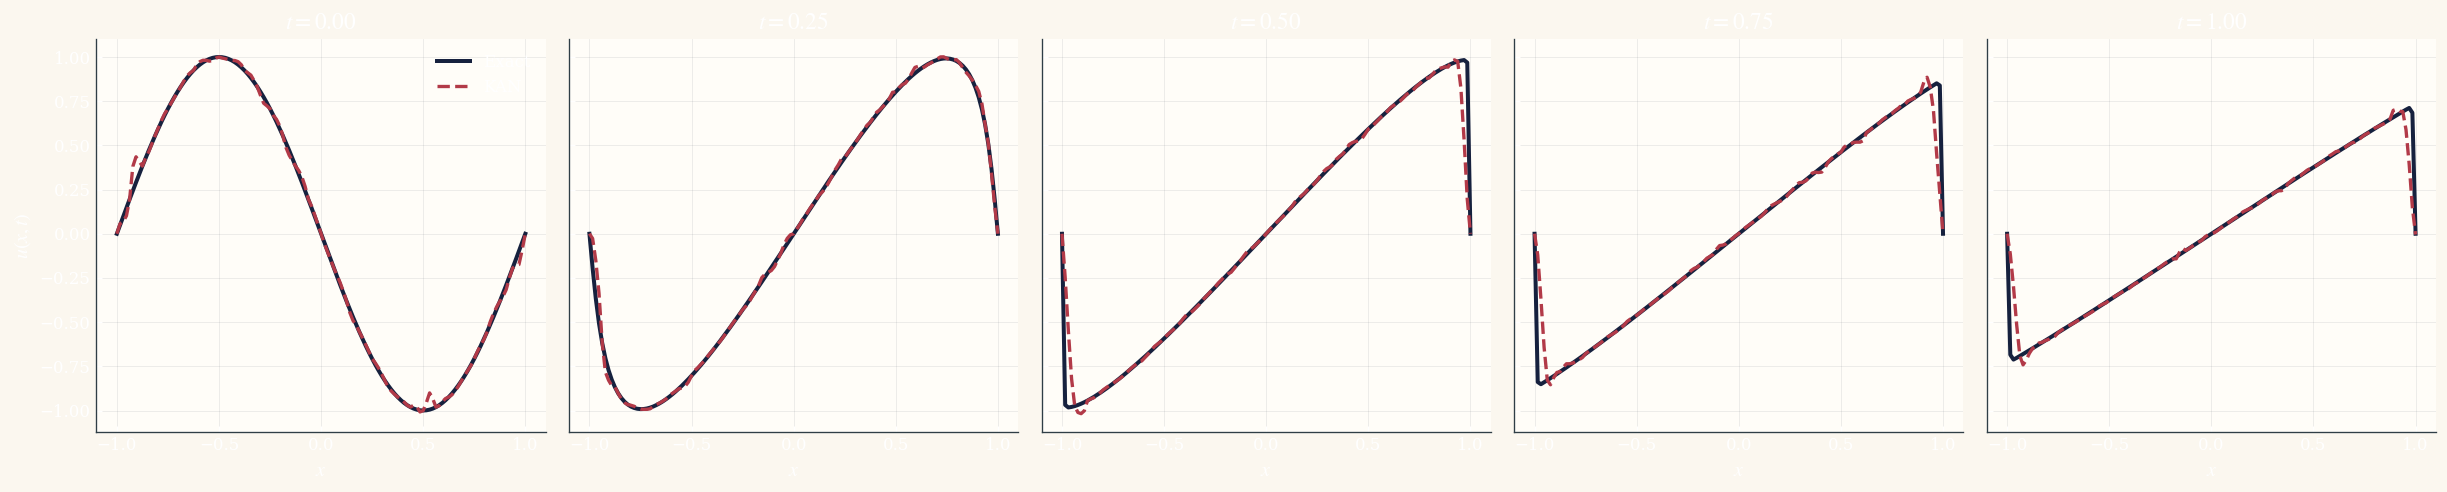

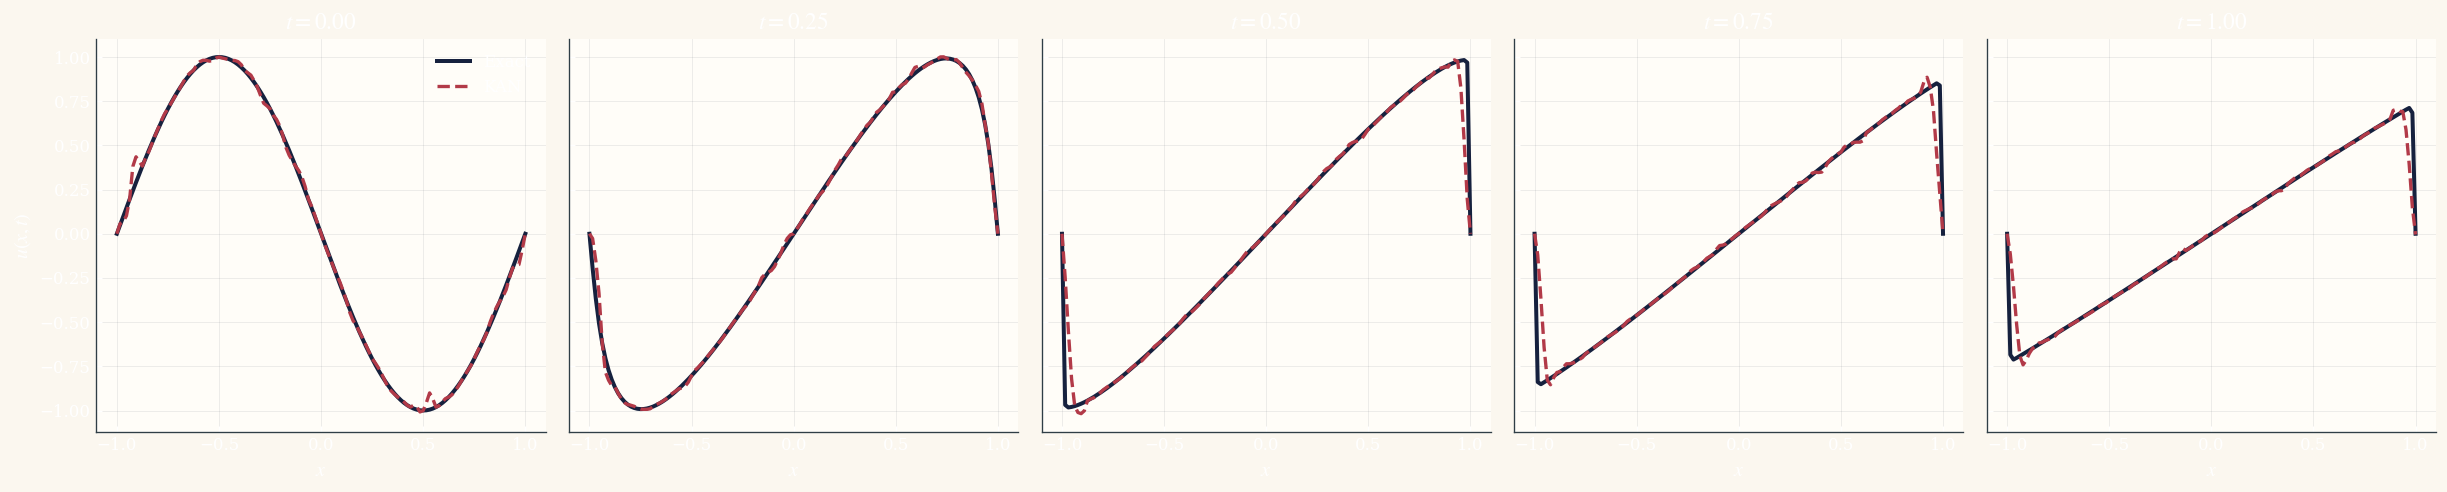

In [8]:
fig_slices = plot_time_slices(experiment.datasets.evaluation, experiment.evaluation_prediction)
fig_slices

## 8 — Verification: PDE Residual of the Learned Surrogate

Even though this model is trained purely by supervised regression, we can still test whether the learned field respects the Burgers equation:

$$
r(x,t) = u_t + u u_x - \nu u_{xx}.
$$

Small residuals do not make the model a PINN, but they are a useful sanity check that the approximation is not merely pointwise accurate while violating the underlying dynamics everywhere else.


In [9]:
residual_metrics = pd.DataFrame([experiment.summary.residual_metrics.model_dump()])
display(residual_metrics)

,mean_absolute_residual,root_mean_square_residual,max_absolute_residual
0,2.644897,7.843973,74.314095


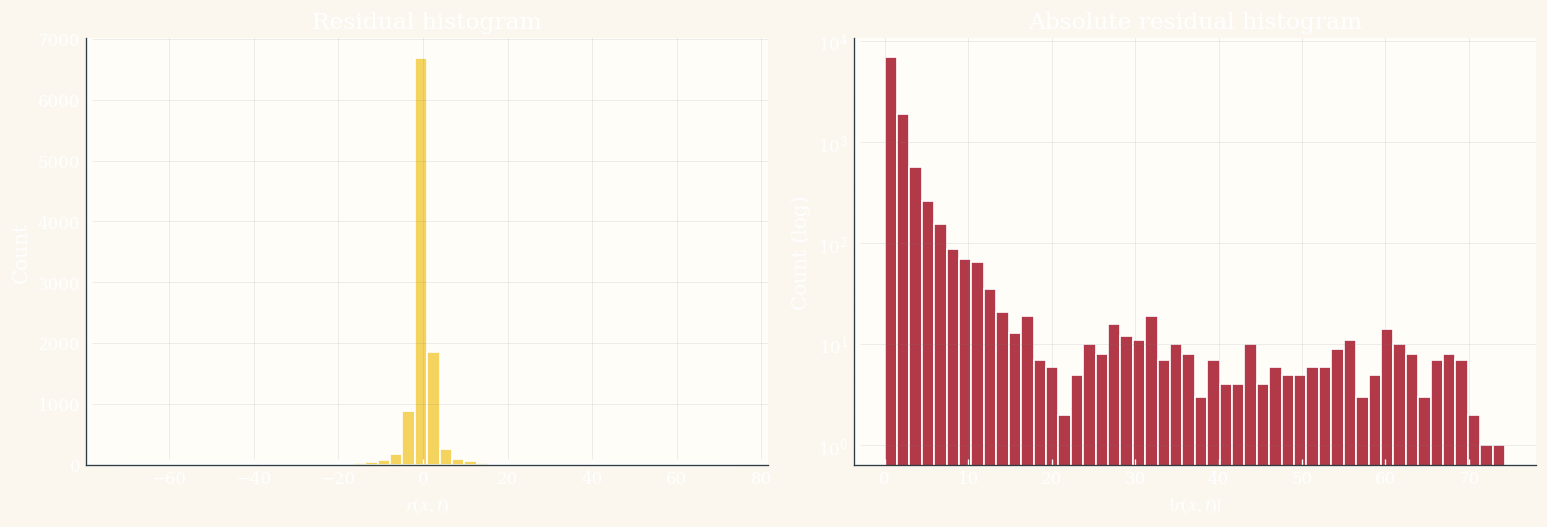

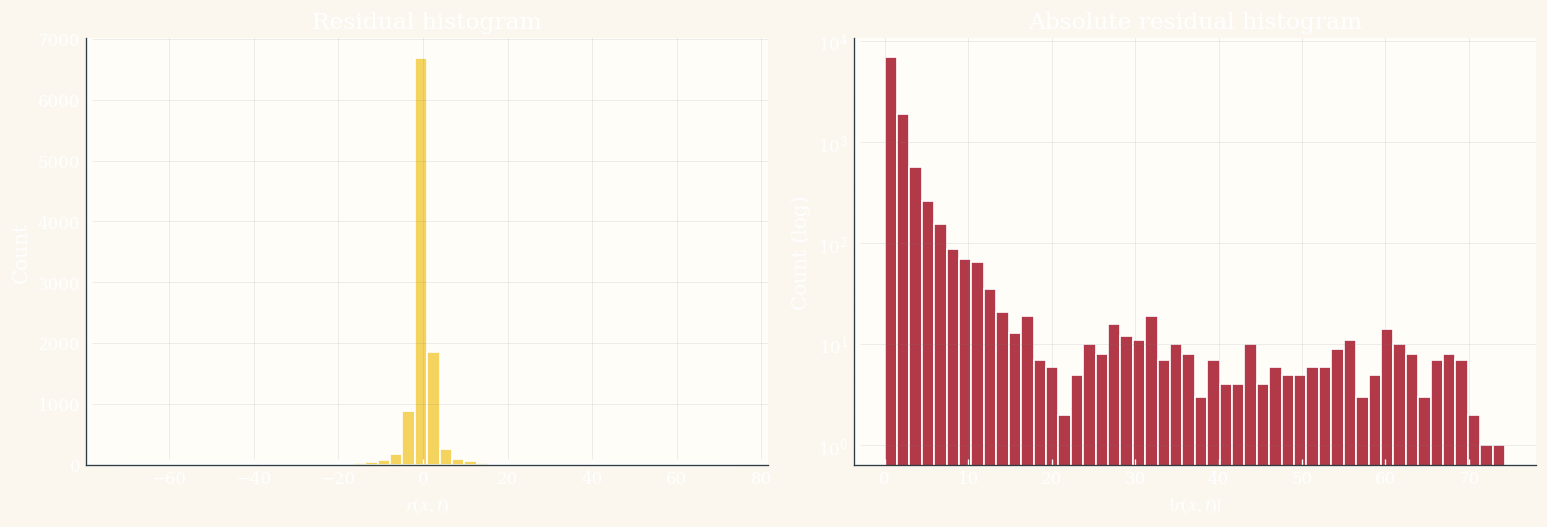

In [10]:
fig_residual = plot_residual_distribution(experiment.residuals)
fig_residual

## 9 — Interpretability: Learned First-Layer Edge Functions

One of the appealing parts of KANs is that the nonlinear structure sits on explicit 1-D edge functions.
For the first layer, those functions are directly interpretable because the inputs are just normalized $x$ and $t$ coordinates.

We inspect several hidden neurons below. Each row corresponds to a hidden neuron and each column corresponds to one input coordinate.


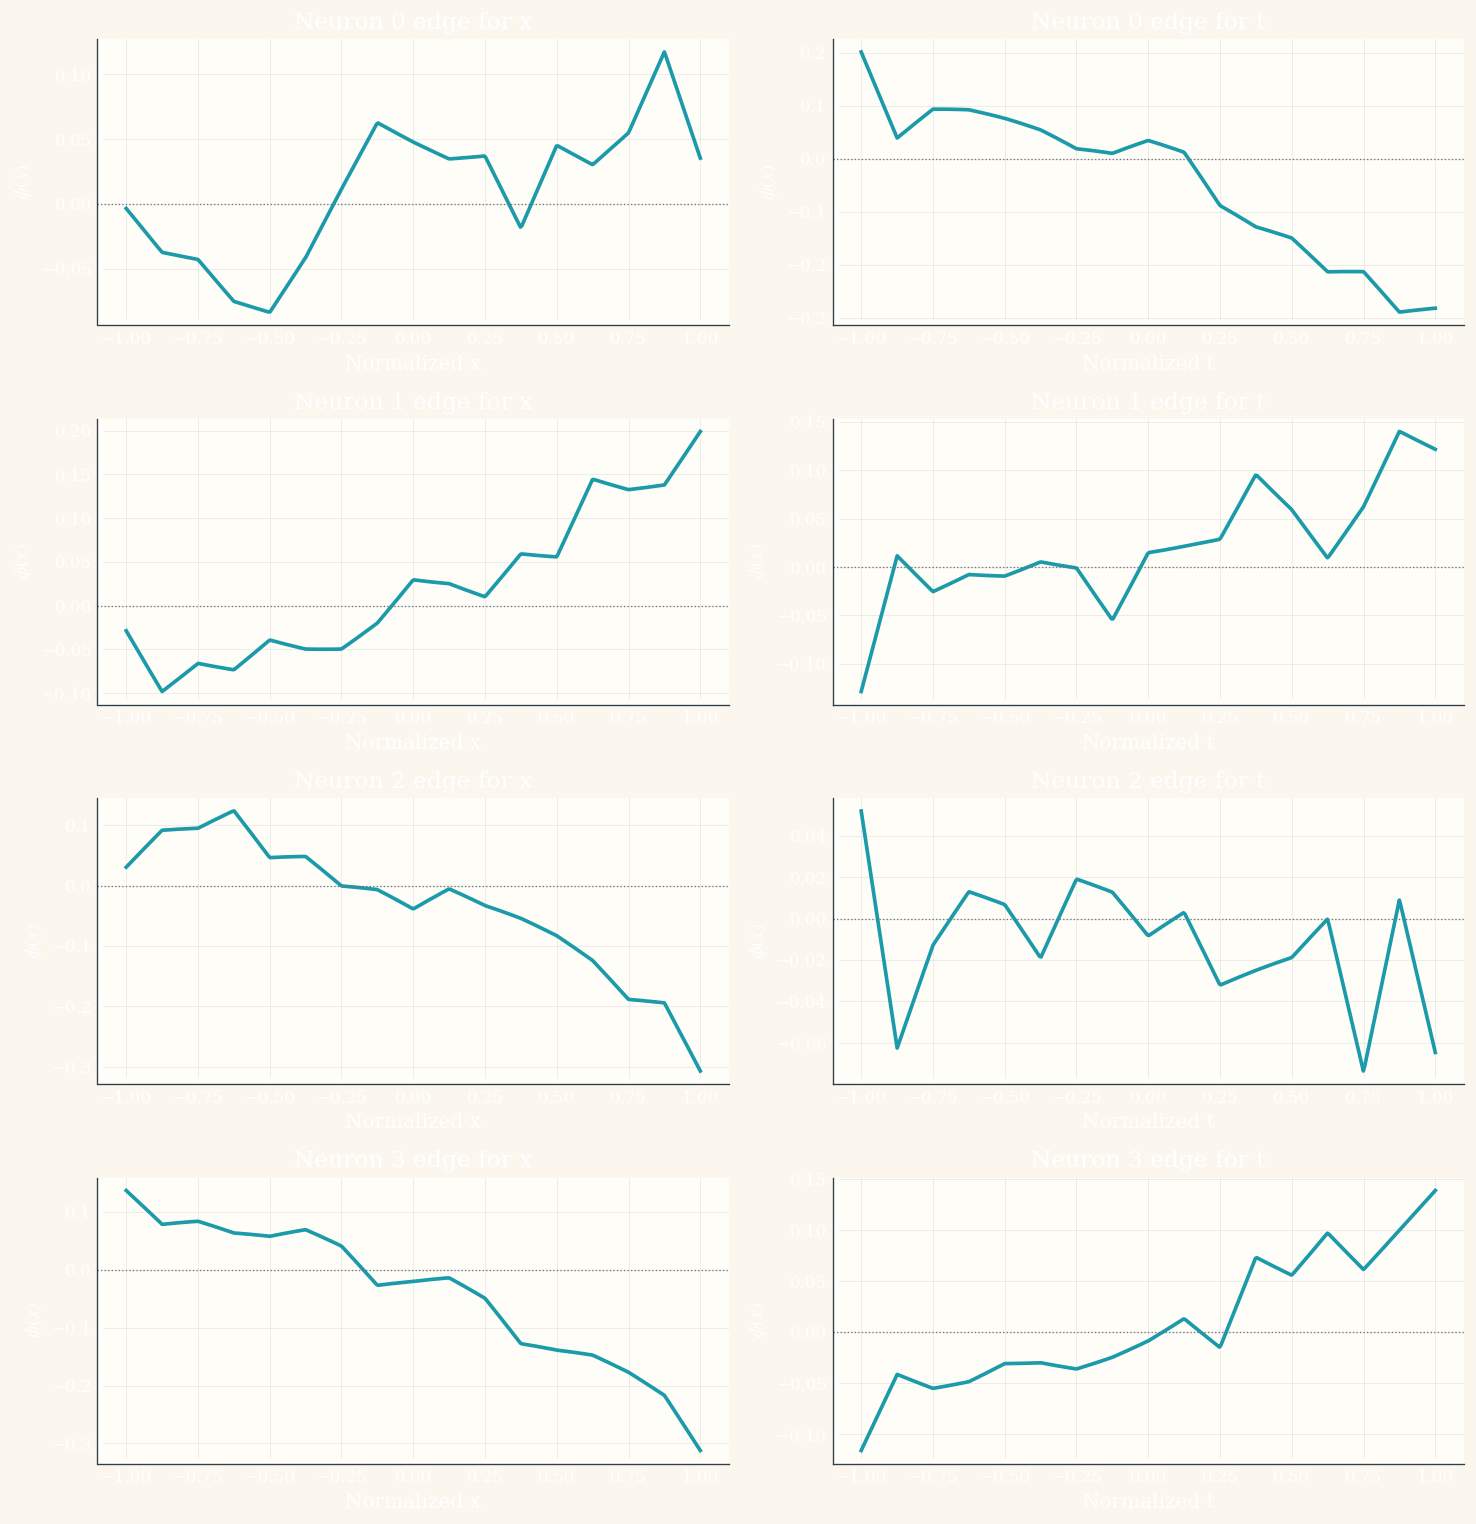

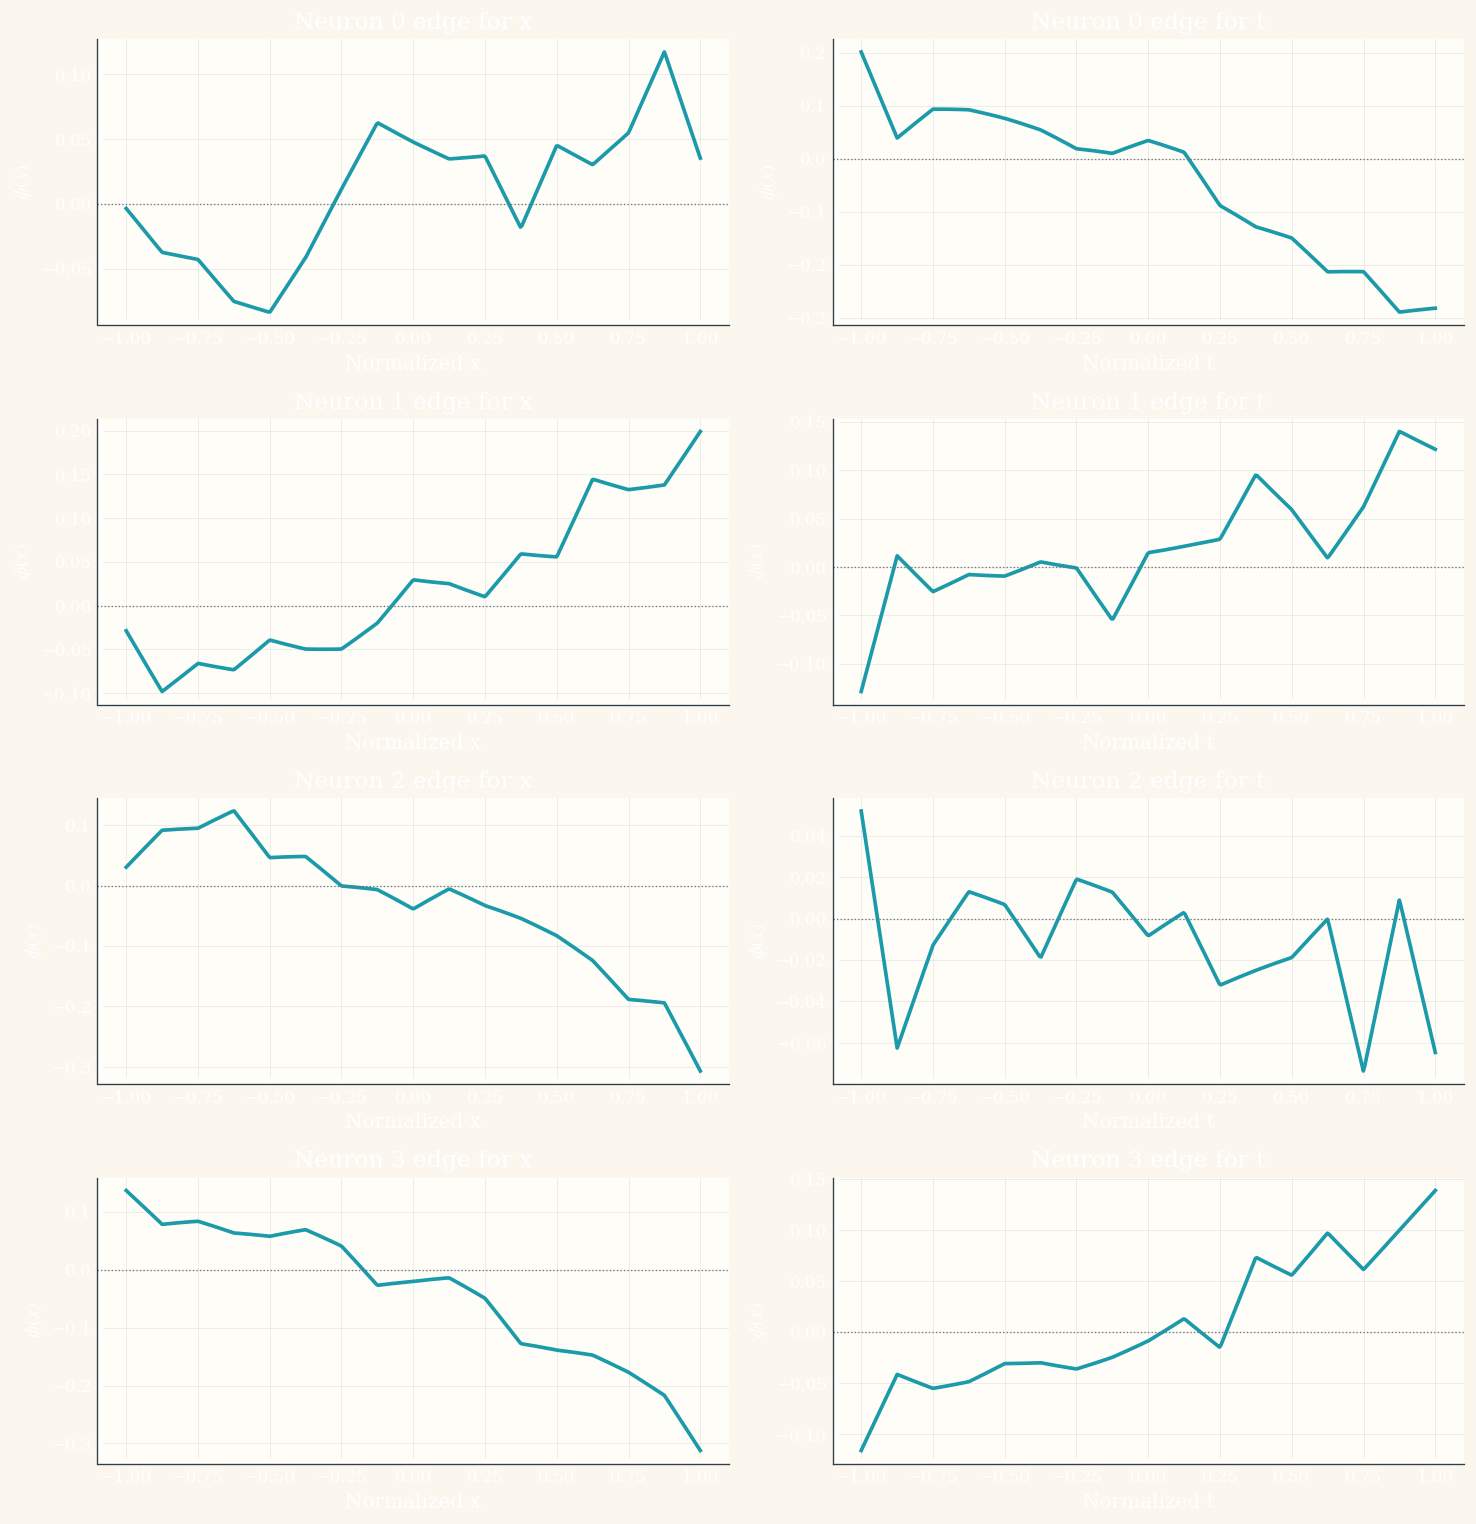

In [11]:
sample_axis = np.linspace(-1.0, 1.0, 400, dtype=np.float32)
sample_tensor = torch.tensor(sample_axis)
edge_responses_torch = experiment.model.evaluate_first_layer_edges(sample_tensor, output_indices=(0, 1, 2, 3))
edge_responses = {
    neuron: {input_idx: response.detach().cpu().numpy() for input_idx, response in edges.items()}
    for neuron, edges in edge_responses_torch.items()
}
fig_edges = plot_edge_functions(sample_axis, edge_responses)
fig_edges

## 10 — Interpreting the Learned Structure

Typical patterns to look for:

- **odd/even structure in $x$ edges** because the Burgers initial condition is sinusoidal and spatially structured
- **time-dependent attenuation** because viscosity damps the solution as $t$ increases
- **nonlinear local corrections** added by the spline component on top of the base activation

These plots do not fully explain the whole network, but they make the first compositional layer much more inspectable than a dense matrix of MLP weights.


## 11 — Limits and Honest Takeaways

This notebook demonstrates what KANs are good at in a scientific-computing workflow:

- compact low-dimensional regression
- explicit univariate nonlinearities
- good visual interpretability for the first layer
- straightforward integration with exact solvers and residual diagnostics

It also shows what KANs are **not**:

- a theorem-powered guarantee of easy training
- a replacement for every MLP or operator model
- a direct substitute for physics-informed losses when constraints must be enforced during optimization

In this repository, the KAN tutorial complements the existing PINN and neural-operator stacks:

- the **PINN** emphasizes physics-constrained optimization
- the **FNO/neural operator** emphasizes learning maps between functions
- the **KAN** emphasizes interpretable function approximation through learned edge nonlinearities
